<h1 style="color:tomato">🛒 Laboratorio Trabajo Final - Market Sales<h1>

#### Diccionario de Datos del Dataset `Market_Analysis_Dirty.csv`

**Invoice ID:** Un identificador único para cada transacción.

**Branch:** Ubicación de la sucursal del supermercado (p. ej., Yangon, Naypyitaw, Mandalay).

**City:** Ciudad donde se encuentra la sucursal.

**Customer Type:** Cliente «Socio» o «Normal».

**Gender:** Género del cliente.

**Product Line:** Categoría del producto (p. ej., Salud y belleza, Accesorios electrónicos).

**Unit Price:** Precio por unidad del producto.

**Quantity:** Número de artículos comprados.

**Tax 5%:** Importe del impuesto basado en una tasa del 5%.

**Total:** Importe total de la transacción, impuestos incluidos.

**Date:** Fecha de la transacción.

**Time:** Hora de la transacción.

**Payment:** Método de pago (Efectivo, Monedero electrónico, Tarjeta de crédito).

**COGS (Cost of Goods Sold):** Costo de los productos vendidos.

**Gross Margin Percentage:** Establecido en 4,7619%.

**Gross Income:** Ganancia por cada transacción.

**Customer Rating:** Puntuación de satisfacción del cliente (sobre 10).

## Parte 1: Carga y Limpieza de Datos (Nivel Básico)

#### 1. Exploración Inicial: Carga el archivo Market_Analysis_Dirty.csv y utiliza los métodos necesarios para identificar cuántos registros y columnas tiene el dataset. ¿Qué tipos de datos detecta Python para cada columna?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Market_Analysis_Dirty.csv")

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7.0,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5.0,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7.0,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8.0,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7.0,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
# 1. Exploración inicial
# Esto responde a:
# Cuántos registros tiene.
# Cuántas columnas tiene.
# Qué columnas existen.
# Qué tipo de dato detectó Python en cada columna.

print("Dimensiones del dataset:")
print(df.shape)

print("\nNúmero de registros:", df.shape[0])
print("Número de columnas:", df.shape[1])

print("\nNombres de las columnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

print("\nInformación general:")
df.info()

Dimensiones del dataset:
(1000, 17)

Número de registros: 1000
Número de columnas: 17

Nombres de las columnas:
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']

Tipos de datos:
Invoice ID                     str
Branch                         str
City                           str
Customer type                  str
Gender                         str
Product line                   str
Unit price                 float64
Quantity                   float64
Tax 5%                     float64
Sales                      float64
Date                           str
Time                           str
Payment                        str
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

Información general:
<class 'pandas.DataFrame'>
Rang

El dataset fue cargado correctamente y se realizó una exploración inicial de sus dimensiones, nombres de columnas y tipos de datos. El conjunto contiene variables numéricas y categóricas relacionadas con las ventas, los productos, los clientes, los métodos de pago y las sucursales.

#### 2. Identificación de Faltantes: Calcula el porcentaje de valores nulos para cada columna. ¿Cuáles son las tres columnas con mayor cantidad de datos faltantes?

In [6]:
porcentaje_nulos = df.isnull().mean() * 100

print("Porcentaje de valores nulos por columna:")
print(porcentaje_nulos.sort_values(ascending=False))

Porcentaje de valores nulos por columna:
Gender                     5.0
Rating                     5.0
Unit price                 5.0
Quantity                   5.0
Payment                    5.0
Invoice ID                 0.0
City                       0.0
Customer type              0.0
Branch                     0.0
Tax 5%                     0.0
Product line               0.0
Date                       0.0
Sales                      0.0
Time                       0.0
cogs                       0.0
gross margin percentage    0.0
gross income               0.0
dtype: float64


In [7]:
# Para obtener las 3 columnas con más datos faltantes:
top_3_nulos = porcentaje_nulos.sort_values(ascending=False).head(3)

print("Las 3 columnas con mayor porcentaje de valores faltantes:")
print(top_3_nulos)

Las 3 columnas con mayor porcentaje de valores faltantes:
Gender        5.0
Rating        5.0
Unit price    5.0
dtype: float64


Se calcularon los porcentajes de valores nulos para cada una de las columnas del dataset. Esto permitió identificar las columnas que presentaban una mayor cantidad de información faltante y establecer posteriormente las estrategias adecuadas para su tratamiento.

#### 3. Tratamiento de Nulos: Para la columna Unit price, imputa los valores faltantes utilizando la mediana. Para la columna Gender, sustituye los valores nulos por la etiqueta "Unknown".

In [11]:
print(df.columns.tolist())

['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']


In [12]:
df['Unit price'] = df['Unit price'].fillna(
    df['Unit price'].median()
)

In [13]:
# Para Gender:
df['Gender'] = df['Gender'].fillna('Unknown')

In [14]:
# Y comprobamos:
print(df[['Unit price', 'Gender']].isnull().sum())

Unit price    0
Gender        0
dtype: int64


Los valores faltantes de la columna Unit price fueron reemplazados utilizando la mediana de dicha variable. Se utilizó la mediana porque es una medida robusta frente a posibles valores extremos. Para la columna Gender, los valores faltantes fueron reemplazados por la categoría "Unknown", permitiendo conservar los registros sin asumir información que no estaba disponible.

#### 4. Normalización de Categorías: En la columna Branch, existen registros como 'Alex ', 'ALEX' y 'Alex'. Utiliza funciones de cadenas de texto para estandarizar todos los registros a un solo formato (ej. mayúsculas).

In [15]:
df['Branch'] = df['Branch'].str.strip().str.upper()

In [16]:
# Y comprobamos:
print(df['Branch'].unique())

<StringArray>
['ALEX', 'GIZA', 'CAIRO']
Length: 3, dtype: str


Se estandarizaron los registros de la columna Branch eliminando espacios innecesarios y convirtiendo todos los valores a mayúsculas. De esta manera, registros como Alex, Alex y ALEX quedan representados de una misma forma, evitando duplicidades en el análisis.

#### 5. Validación Lógica: Identifica si existen registros donde el Unit price sea menor o igual a cero. Si los hay, elimínalos del DataFrame o corrígelos justificando tu decisión.

In [17]:
precios_invalidos = df[df['Unit price'] <= 0]

print("Cantidad de precios inválidos:", len(precios_invalidos))
print(precios_invalidos)

Cantidad de precios inválidos: 5
      Invoice ID Branch       City Customer type  Gender  \
520  734-91-1155  CAIRO   Mandalay        Normal  Female   
577  592-34-6155   GIZA  Naypyitaw        Normal    Male   
698  868-06-0466   ALEX     Yangon        Member    Male   
763  587-73-4862   ALEX     Yangon        Member  Female   
790  651-96-5970   ALEX     Yangon        Normal    Male   

               Product line  Unit price  Quantity   Tax 5%     Sales  \
520  Electronic accessories       -10.0       3.0   6.8565  143.9865   
577      Food and beverages       -10.0       4.0   6.3540  133.4340   
698  Electronic accessories       -10.0       9.0  31.3110  657.5310   
763       Health and beauty       -10.0       5.0   2.6725   56.1225   
790     Fashion accessories       -10.0       1.0   2.3205   48.7305   

          Date         Time      Payment    cogs  gross margin percentage  \
520  3/26/2019  10:34:00 AM  Credit card  137.13                 4.761905   
577  1/14/2019   2:

In [18]:
# Si existen registros inválidos, los eliminamos:
df = df[df['Unit price'] > 0].copy()

In [19]:
# Y comprobamos:
print((df['Unit price'] <= 0).sum())

0


Se revisaron los registros de la columna Unit price para identificar valores menores o iguales a cero. Los registros que no cumplían con la lógica de un precio de venta válido fueron eliminados, debido a que un precio unitario menor o igual a cero no representa una transacción de venta válida dentro del contexto del dataset.

## Parte 2: Transformación y Estadísticas Descriptivas (Nivel Intermedio)

#### 6. Manejo de Outliers: Utilizando el método del Rango Intercuartílico (IQR), identifica si la columna Quantity tiene valores atípicos (outliers). Si existen compras con cantidades exageradas (como 50), sepáralas en un nuevo DataFrame para un análisis especial.

In [20]:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Q1: 3.0
Q3: 8.0
IQR: 5.0
Límite inferior: -4.5
Límite superior: 15.5


In [21]:
# Creamos el DataFrame de outliers:
outliers_quantity = df[
    (df['Quantity'] < limite_inferior) |
    (df['Quantity'] > limite_superior)
].copy()

print("Cantidad de outliers:", len(outliers_quantity))

outliers_quantity[['Invoice ID', 'Quantity']]

Cantidad de outliers: 5


,Invoice ID,Quantity
22,273-16-6619,50.0
399,346-12-3257,50.0
438,549-96-4200,50.0
909,624-01-8356,50.0
978,156-20-0370,50.0


Se utilizó el método del Rango Intercuartílico (IQR) para identificar valores atípicos en la columna Quantity. Los registros considerados outliers fueron separados en un DataFrame independiente para realizar un análisis especial, evitando eliminarlos directamente del conjunto de datos original.

#### 7. Ingeniería de Características (Fechas): Convierte la columna Date al formato datetime. Crea una nueva columna llamada Month y determina en qué mes se registró el mayor volumen de ventas totales.

In [22]:
df['Date'] = pd.to_datetime(df['Date'])

In [23]:
# Creamos Month:
df['Month'] = df['Date'].dt.month

In [24]:
# Ventas por mes:
ventas_por_mes = df.groupby('Month')['Sales'].sum()

print(ventas_por_mes)

Month
1    116158.4340
2     96561.8430
3    109206.6675
Name: Sales, dtype: float64


In [25]:
# Mes con mayor volumen:
mes_mayor_venta = ventas_por_mes.idxmax()
total_mayor_venta = ventas_por_mes.max()

print("Mes con mayor volumen de ventas:", mes_mayor_venta)
print("Total vendido:", total_mayor_venta)

Mes con mayor volumen de ventas: 1
Total vendido: 116158.434


La columna Date fue convertida al formato datetime y se creó una nueva columna llamada Month, que permite identificar el mes correspondiente a cada transacción. Posteriormente, se agruparon las ventas por mes para determinar cuál presentó el mayor volumen de ventas durante el periodo analizado.

#### 8. Análisis por Grupo: Calcula el promedio de Rating y el total de Sales por cada Product line. ¿Cuál es la categoría de producto mejor valorada por los clientes?

In [26]:
# Aquí utilizaremos Product line, Rating y Sales:
analisis_productos = df.groupby('Product line').agg(
    Promedio_Rating=('Rating', 'mean'),
    Total_Ventas=('Sales', 'sum')
)

print(analisis_productos)

                        Promedio_Rating  Total_Ventas
Product line                                         
Electronic accessories         6.890385    53419.1070
Fashion accessories            7.104192    52903.3365
Food and beverages             7.169277    55471.7415
Health & Beauty                7.400000     3839.9760
Health and beauty              7.073239    49137.6165
Home and lifestyle             6.918792    52392.5220
Sports and travel              6.869032    54762.6450


In [27]:
# Categoría mejor valorada:
mejor_categoria = analisis_productos['Promedio_Rating'].idxmax()
mejor_rating = analisis_productos['Promedio_Rating'].max()

print("Categoría mejor valorada:", mejor_categoria)
print("Rating promedio:", mejor_rating)

Categoría mejor valorada: Health & Beauty
Rating promedio: 7.4


Se calculó el promedio de Rating y el total de Sales para cada categoría de Product line. Este análisis permitió identificar la categoría de producto que obtuvo la mejor valoración promedio por parte de los clientes y comparar el volumen de ventas entre las diferentes líneas de productos.

#### 9. Filtros Complejos: Genera un subset de datos que contenga solo las ventas realizadas en la ciudad de 'Yangon', que hayan sido pagadas con 'Ewallet' y cuyo Rating sea superior a 7.

In [28]:
subset = df[
    (df['City'] == 'Yangon') &
    (df['Payment'] == 'Ewallet') &
    (df['Rating'] > 7)
].copy()

print("Cantidad de ventas encontradas:", len(subset))

subset

Cantidad de ventas encontradas: 61


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Month
0,750-67-8428,ALEX,Yangon,Member,Female,Health and beauty,74.69,7.0,26.1415,548.9715,2019-01-05,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1,1
3,123-19-1176,ALEX,Yangon,Member,Female,Health and beauty,58.22,8.0,23.2880,489.0480,2019-01-27,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4,1
12,365-64-0515,ALEX,Yangon,Member,Female,Electronic accessories,46.95,5.0,11.7375,246.4875,2019-02-12,10:25:00 AM,Ewallet,234.75,4.761905,11.7375,7.1,2
13,252-56-2699,ALEX,Yangon,Member,Female,Food and beverages,43.19,10.0,21.5950,453.4950,2019-02-07,4:48:00 PM,Ewallet,431.90,4.761905,21.5950,8.2,2
23,636-48-8204,ALEX,Yangon,Member,Female,Electronic accessories,34.56,5.0,8.6400,181.4400,2019-02-17,11:15:00 AM,Ewallet,172.80,4.761905,8.6400,9.9,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,884-80-6021,ALEX,Yangon,Member,Female,Electronic accessories,73.47,10.0,36.7350,771.4350,2019-03-23,1:14:00 PM,Ewallet,734.70,4.761905,36.7350,9.5,3
913,522-57-8364,ALEX,Yangon,Member,Male,Fashion accessories,51.34,8.0,20.5360,431.2560,2019-01-31,10:00:00 AM,Ewallet,410.72,4.761905,20.5360,7.6,1
966,558-60-5016,ALEX,Yangon,Normal,Female,Home and lifestyle,33.30,9.0,14.9850,314.6850,2019-03-04,3:27:00 PM,Ewallet,299.70,4.761905,14.9850,7.2,3
982,139-32-4183,ALEX,Yangon,Member,Female,Sports and travel,97.48,9.0,43.8660,921.1860,2019-03-14,2:19:00 PM,Ewallet,877.32,4.761905,43.8660,7.4,3


Se generó un subconjunto de datos que contiene únicamente las ventas realizadas en la ciudad de Yangon, pagadas mediante Ewallet y cuyo Rating es superior a 7. Este filtro permite analizar específicamente las transacciones realizadas bajo estas tres condiciones.

#### 10. Análisis de Clientes: Determina si existe una diferencia significativa en el promedio de gasto (Total) entre los clientes de tipo 'Member' y 'Normal'.

In [29]:
# La columna es Customer type y las ventas son Sales:

gasto_promedio = df.groupby('Customer type')['Sales'].mean()

print(gasto_promedio)

Customer type
Member    335.668047
Normal    307.744986
Name: Sales, dtype: float64


In [30]:
# Comparación:
member = gasto_promedio['Member']
normal = gasto_promedio['Normal']

print("Gasto promedio Member:", member)
print("Gasto promedio Normal:", normal)
print("Diferencia:", abs(member - normal))

Gasto promedio Member: 335.6680470692718
Gasto promedio Normal: 307.74498611111113
Diferencia: 27.923060958160647


Se comparó el promedio de gasto, utilizando la variable Sales, entre los clientes de tipo Member y Normal. El análisis permitió determinar qué tipo de cliente presenta un mayor gasto promedio y observar las diferencias existentes entre ambos grupos.

## Parte 3: Análisis Avanzado y Visualización (Nivel Avanzado)

#### 11. Análisis de Correlación: Genera una matriz de correlación entre las variables numéricas. ¿Existe alguna relación fuerte entre el precio unitario y la calificación (Rating) otorgada por el cliente?

In [31]:
variables_numericas = df.select_dtypes(include='number')

correlacion = variables_numericas.corr()

print(correlacion)

                         Unit price  Quantity    Tax 5%     Sales      cogs  \
Unit price                 1.000000 -0.044754  0.628869  0.628869  0.628869   
Quantity                  -0.044754  1.000000  0.435117  0.435117  0.435117   
Tax 5%                     0.628869  0.435117  1.000000  1.000000  1.000000   
Sales                      0.628869  0.435117  1.000000  1.000000  1.000000   
cogs                       0.628869  0.435117  1.000000  1.000000  1.000000   
gross margin percentage         NaN       NaN       NaN       NaN       NaN   
gross income               0.628869  0.435117  1.000000  1.000000  1.000000   
Rating                    -0.014322 -0.064639 -0.052893 -0.052893 -0.052893   
Month                     -0.029455  0.031691 -0.019801 -0.019801 -0.019801   

                         gross margin percentage  gross income    Rating  \
Unit price                                   NaN      0.628869 -0.014322   
Quantity                                     NaN      0.4

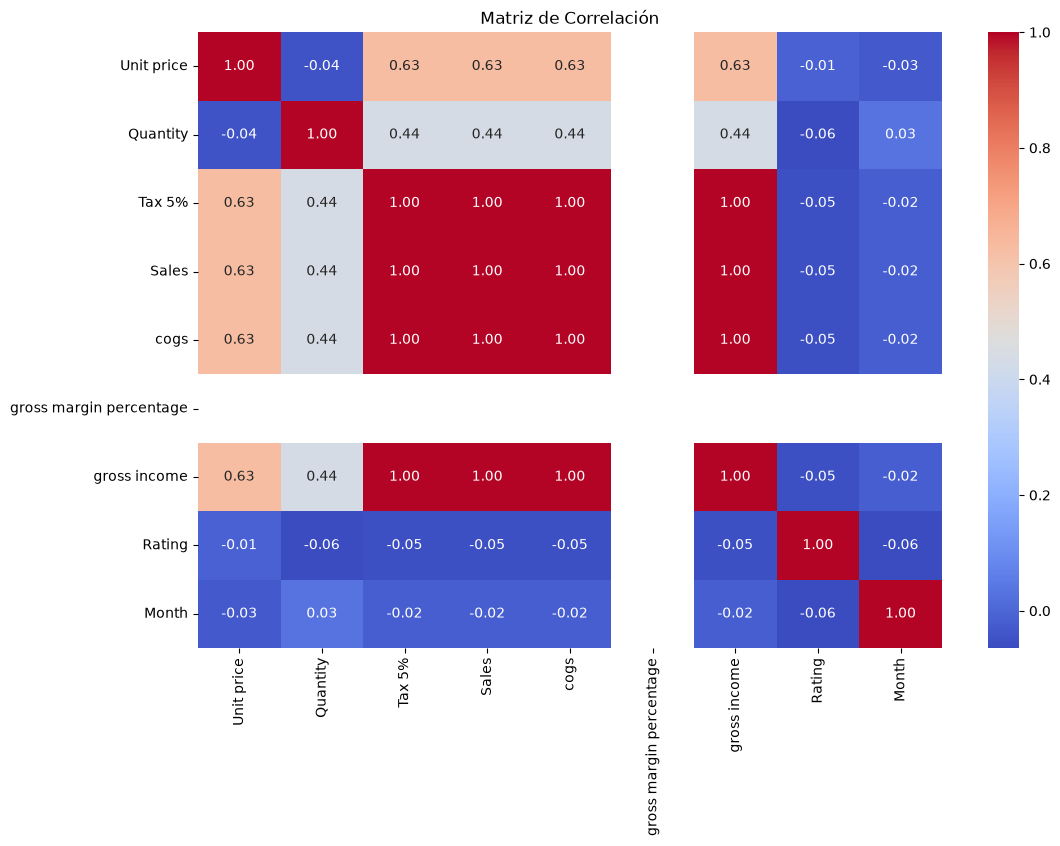

In [32]:
# Heatmap:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de Correlación')
plt.show()

In [33]:
# Y específicamente:
correlacion_precio_rating = correlacion.loc[
    'Unit price',
    'Rating'
]

print(
    "Correlación entre Unit price y Rating:",
    correlacion_precio_rating
)

Correlación entre Unit price y Rating: -0.014322461741245256


Se generó una matriz de correlación entre las variables numéricas del dataset. También se analizó específicamente la relación entre Unit price y Rating. La correlación permite determinar si existe una relación lineal entre el precio unitario y la calificación otorgada por los clientes.

#### 12. Visualización de Distribuciones: Crea un histograma de la columna Rating con un estimador de densidad de núcleo (KDE). Describe si la satisfacción del cliente sigue una distribución normal o si está sesgada.

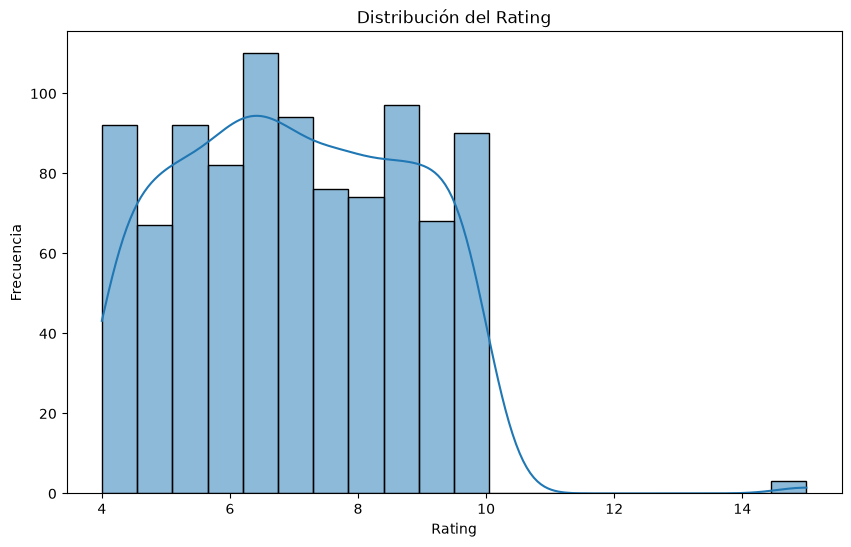

In [34]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['Rating'],
    bins=20,
    kde=True
)

plt.title('Distribución del Rating')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')

plt.show()

In [35]:
# Sesgo:
sesgo = df['Rating'].skew()

print("Sesgo:", sesgo)

Sesgo: 0.266550278171239


Se generó un histograma de la variable Rating acompañado de un estimador de densidad de núcleo (KDE). Esta visualización permitió analizar la distribución de las calificaciones y determinar si los datos presentan una distribución aproximadamente normal o algún grado de sesgo.

#### 13. Comportamiento Temporal: Realiza un gráfico de líneas que muestre la tendencia de ventas diarias a lo largo de todo el periodo registrado. ¿Se observa algún patrón o pico de ventas específico?

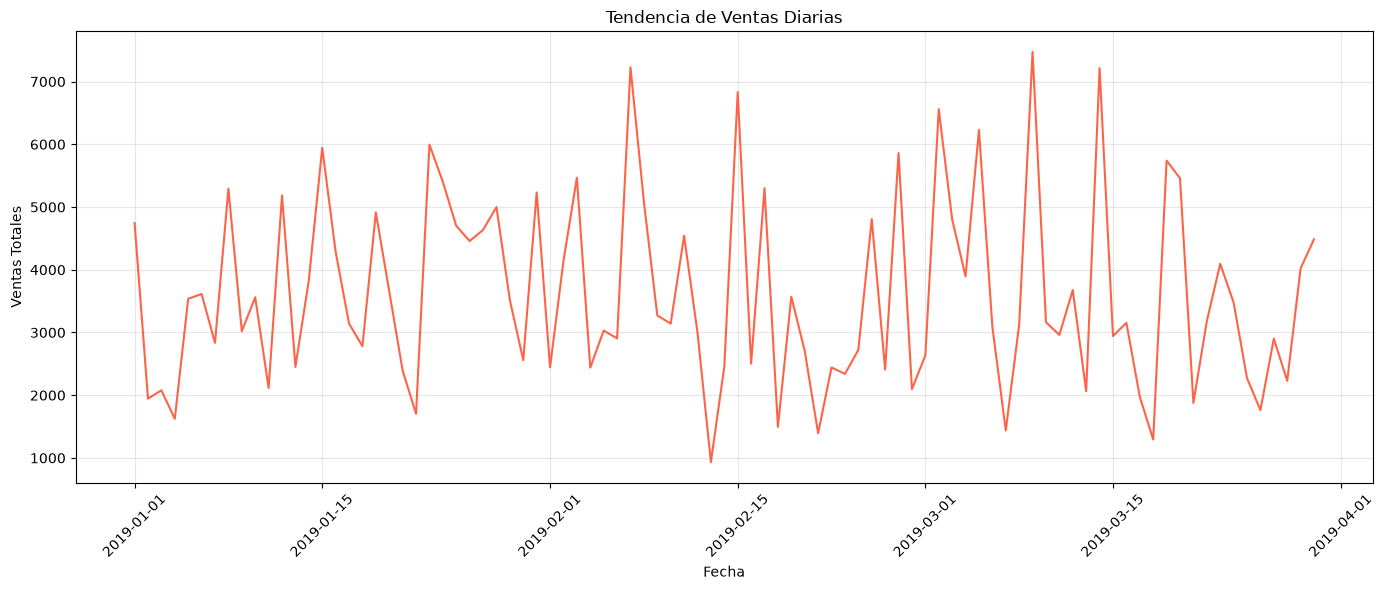

In [36]:
ventas_diarias = df.groupby('Date')['Sales'].sum()

plt.figure(figsize=(14, 6))

plt.plot(
    ventas_diarias.index,
    ventas_diarias.values,
    color='tomato'
)

plt.title('Tendencia de Ventas Diarias')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Se realizó un gráfico de líneas para representar la tendencia de las ventas diarias durante todo el periodo registrado. La visualización permitió identificar variaciones, aumentos y disminuciones en las ventas, así como posibles picos de actividad comercial.

#### 14. Segmentación de Mercado: Crea una tabla dinámica (pivot table) que muestre el total de ingresos (gross income) desglosado por City en las filas y Payment en las columnas. Visualiza este resultado mediante un mapa de calor (Heatmap).

In [37]:
# En el CSV es gross income:

pivot = pd.pivot_table(
    df,
    values='gross income',
    index='City',
    columns='Payment',
    aggfunc='sum'
)

print(pivot)

Payment         Cash  Credit card   Ewallet
City                                       
Mandalay   1667.1950    1705.6940  1513.032
Naypyitaw  1949.7190    1394.2035  1665.631
Yangon     1446.1455    1466.9950  1787.618


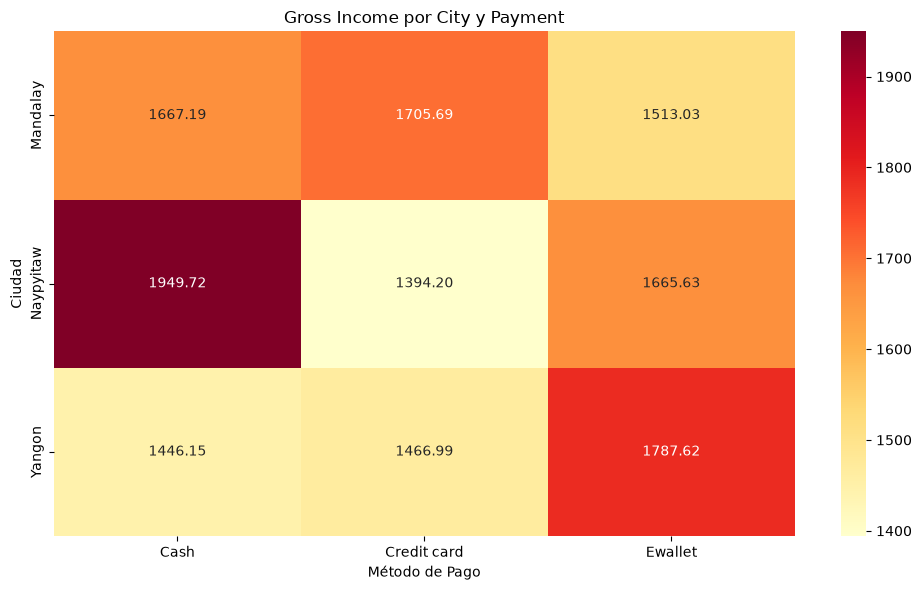

In [38]:
# Heatmap:
plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd'
)

plt.title('Gross Income por City y Payment')
plt.xlabel('Método de Pago')
plt.ylabel('Ciudad')

plt.tight_layout()
plt.show()

Se construyó una tabla dinámica que muestra el Gross Income desglosado por City en las filas y Payment en las columnas. Posteriormente, los resultados fueron representados mediante un mapa de calor. Esta visualización permite identificar de manera sencilla las ciudades y métodos de pago asociados con mayores niveles de ingreso bruto.

#### 15. Preparación para Machine Learning: Supongamos que queremos predecir el Rating. Identifica qué columnas categóricas deberían ser transformadas mediante One-Hot Encoding y cuáles numéricas deberían ser escaladas para que un modelo de regresión lineal funcione correctamente.

In [39]:
# Tu variable objetivo es:
y = df['Rating']

In [40]:
# Y las variables predictoras:
X = df.drop('Rating', axis=1)

In [41]:
# Categóricas:
columnas_categoricas = X.select_dtypes(
    include='object'
).columns

print("Variables categóricas:")
print(columnas_categoricas.tolist())

Variables categóricas:
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Time', 'Payment']


C:\Users\ESTUDIANTE\AppData\Local\Temp\ipykernel_15520\3987155152.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = X.select_dtypes(


In [42]:
# Numéricas:
columnas_numericas = X.select_dtypes(
    include='number'
).columns

print("Variables numéricas:")
print(columnas_numericas.tolist())

Variables numéricas:
['Unit price', 'Quantity', 'Tax 5%', 'Sales', 'cogs', 'gross margin percentage', 'gross income', 'Month']


In [43]:
# Para One-Hot Encoding:
X_encoded = pd.get_dummies(
    X,
    columns=columnas_categoricas,
    drop_first=True
)

X_encoded.head()

,Unit price,Quantity,Tax 5%,Sales,Date,cogs,gross margin percentage,gross income,Month,Invoice ID_101-81-4070,...,Time_8:48:00 PM,Time_8:50:00 PM,Time_8:51:00 PM,Time_8:52:00 PM,Time_8:54:00 PM,Time_8:55:00 PM,Time_8:57:00 PM,Time_8:59:00 PM,Payment_Credit card,Payment_Ewallet
0,74.69,7.0,26.1415,548.9715,2019-01-05,522.83,4.761905,26.1415,1,False,...,False,False,False,False,False,False,False,False,False,True
1,15.28,5.0,3.8200,80.2200,2019-03-08,76.40,4.761905,3.8200,3,False,...,False,False,False,False,False,False,False,False,False,False
2,46.33,7.0,16.2155,340.5255,2019-03-03,324.31,4.761905,16.2155,3,False,...,False,False,False,False,False,False,False,False,True,False
3,58.22,8.0,23.2880,489.0480,2019-01-27,465.76,4.761905,23.2880,1,False,...,False,False,False,False,False,False,False,False,False,True
4,86.31,7.0,30.2085,634.3785,2019-02-08,604.17,4.761905,30.2085,2,False,...,False,False,False,False,False,False,False,False,False,True


In [44]:
# Y para escalar:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = X_encoded.copy()

X_scaled[columnas_numericas] = scaler.fit_transform(
    X_scaled[columnas_numericas]
)

X_scaled.head()

,Unit price,Quantity,Tax 5%,Sales,Date,cogs,gross margin percentage,gross income,Month,Invoice ID_101-81-4070,...,Time_8:48:00 PM,Time_8:50:00 PM,Time_8:51:00 PM,Time_8:52:00 PM,Time_8:54:00 PM,Time_8:55:00 PM,Time_8:57:00 PM,Time_8:59:00 PM,Payment_Credit card,Payment_Ewallet
0,0.729995,0.287049,0.917443,0.917443,2019-01-05,0.917443,0.0,0.917443,-1.187474,False,...,False,False,False,False,False,False,False,False,False,True
1,-1.557296,-0.173497,-0.990284,-0.990284,2019-03-08,-0.990284,0.0,-0.990284,1.209152,False,...,False,False,False,False,False,False,False,False,False,False
2,-0.361868,0.287049,0.069109,0.069109,2019-03-03,0.069109,0.0,0.069109,1.209152,False,...,False,False,False,False,False,False,False,False,True,False
3,0.095898,0.517322,0.673566,0.673566,2019-01-27,0.673566,0.0,0.673566,-1.187474,False,...,False,False,False,False,False,False,False,False,False,True
4,1.177366,0.287049,1.265033,1.265033,2019-02-08,1.265033,0.0,1.265033,0.010839,False,...,False,False,False,False,False,False,False,False,False,True


Para predecir la variable Rating, las variables categóricas deben transformarse mediante One-Hot Encoding. Entre ellas se encuentran Branch, City, Customer type, Gender, Product line y Payment.

Las variables numéricas, como Unit price, Quantity, Tax 5%, Sales, cogs, gross margin percentage y gross income, pueden ser escaladas para colocar sus valores en escalas comparables. De esta manera, los datos quedan preparados para ser utilizados en un modelo de regresión lineal.